In [2]:
import numpy as np
import pandas as py
import matplotlib.pyplot as plt
df=py.read_csv("rawdata1.csv")
print(df.shape)
print(df.columns)

(20538, 43)
Index(['Age of the patient', 'Blood pressure (mm/Hg)',
       'Specific gravity of urine', 'Albumin in urine', 'Sugar in urine',
       'Red blood cells in urine', 'Pus cells in urine',
       'Pus cell clumps in urine', 'Bacteria in urine',
       'Random blood glucose level (mg/dl)', 'Blood urea (mg/dl)',
       'Serum creatinine (mg/dl)', 'Sodium level (mEq/L)',
       'Potassium level (mEq/L)', 'Hemoglobin level (gms)',
       'Packed cell volume (%)', 'White blood cell count (cells/cumm)',
       'Red blood cell count (millions/cumm)', 'Hypertension (yes/no)',
       'Diabetes mellitus (yes/no)', 'Coronary artery disease (yes/no)',
       'Appetite (good/poor)', 'Pedal edema (yes/no)', 'Anemia (yes/no)',
       'Estimated Glomerular Filtration Rate (eGFR)',
       'Urine protein-to-creatinine ratio', 'Urine output (ml/day)',
       'Serum albumin level', 'Cholesterol level',
       'Parathyroid hormone (PTH) level', 'Serum calcium level',
       'Serum phosphate level'

<class 'pandas.Series'>


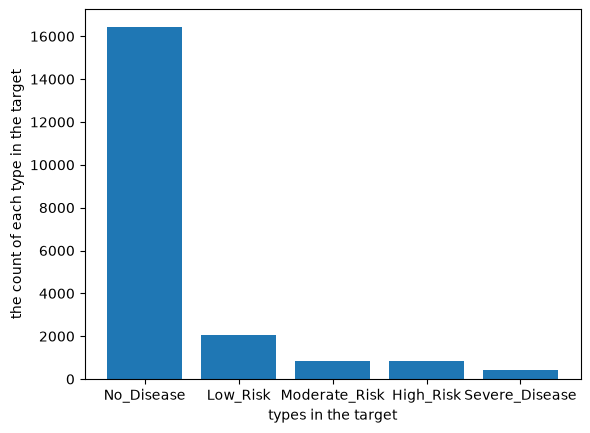

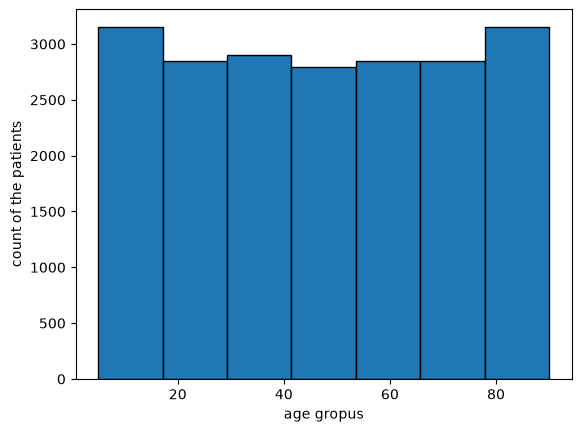

In [4]:
counti=df["Target"].value_counts();
print(type(counti))
plt.bar(counti.index,counti.values)
plt.xlabel("types in the target")
plt.ylabel("the count of each type in the target")
plt.show()
plt.hist(df["Age of the patient"],bins=7,edgecolor="black")
plt.xlabel("age gropus")
plt.ylabel("count of the patients")
plt.show()

In [5]:
print(df["Age of the patient"].value_counts())
print(df["Age of the patient"].describe())
print(df["Age of the patient"].max())
print(df["Age of the patient"].min())
print(df["Age of the patient"].median())

Age of the patient
87    279
89    278
12    265
14    262
69    261
     ... 
21    216
44    214
30    214
39    210
77    193
Name: count, Length: 86, dtype: int64
count    20538.000000
mean        47.477895
std         24.941947
min          5.000000
25%         26.000000
50%         47.000000
75%         69.000000
max         90.000000
Name: Age of the patient, dtype: float64
90
5
47.0


                max  min  median        std
Target                                     
High_Risk        90    5    46.0  25.107453
Low_Risk         90    5    46.0  24.972309
Moderate_Risk    90    5    46.0  24.711127
No_Disease       90    5    48.0  24.960181
Severe_Disease   90    5    44.5  24.122532


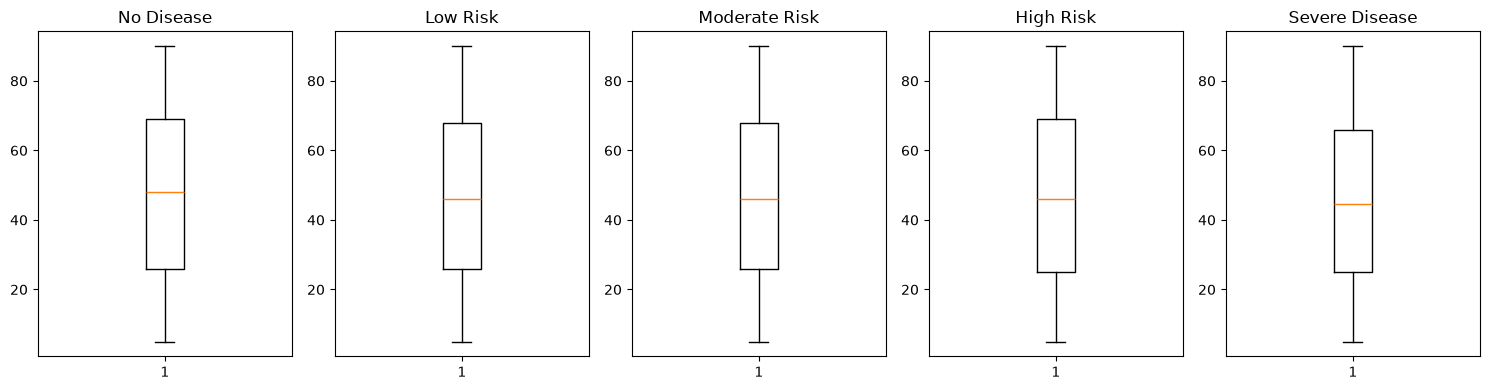

In [7]:
dftemp = df[["Target", "Age of the patient"]]
groups = dftemp.groupby("Target")["Age of the patient"]
a = groups.get_group("No_Disease").tolist()
b = groups.get_group("Low_Risk").tolist()
c = groups.get_group("Moderate_Risk").tolist()
d = groups.get_group("High_Risk").tolist()
e = groups.get_group("Severe_Disease").tolist()
print(dftemp.groupby("Target")["Age of the patient"].agg( ["max", "min", "median", "std"]))
fig, axes = plt.subplots(1, 5, figsize=(15, 4))
axes[0].set_title("No Disease")
axes[1].set_title("Low Risk")
axes[2].set_title("Moderate Risk")
axes[3].set_title("High Risk")
axes[4].set_title("Severe Disease")
axes[0].boxplot(a)
axes[1].boxplot(b)
axes[2].boxplot(c)
axes[3].boxplot(d)
axes[4].boxplot(e)
plt.tight_layout()
plt.show()

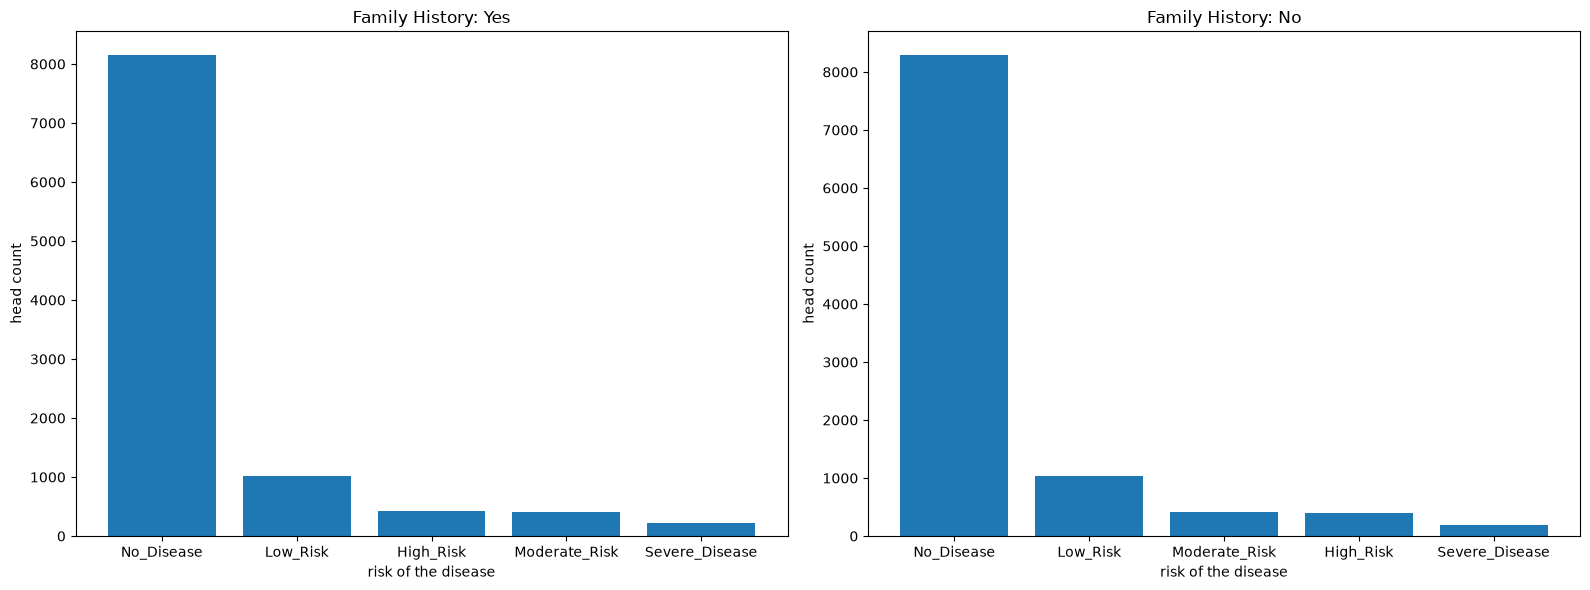

In [21]:
step=df[["Family history of chronic kidney disease","Target"]]
curr=df.groupby("Family history of chronic kidney disease")["Target"]
true=curr.get_group("yes").value_counts()
false=curr.get_group("no").value_counts()
fig,axs=plt.subplots(1,2,figsize=(16,6))
axs[0].bar(true.index,true.values)
axs[0].set_xlabel("risk of the disease")
axs[0].set_ylabel("head count")
axs[1].bar(false.index,false.values)
axs[1].set_xlabel("risk of the disease")
axs[1].set_ylabel("head count")
axs[0].set_title("Family History: Yes")
axs[1].set_title("Family History: No")
plt.tight_layout()
plt.show()

      Diabetes mellitus (yes/no)      Target
0                            yes  No_Disease
1                            yes    Low_Risk
2                             no  No_Disease
3                             no  No_Disease
4                             no  No_Disease
...                          ...         ...
20533                        yes  No_Disease
20534                        yes  No_Disease
20535                        yes  No_Disease
20536                         no  No_Disease
20537                         no  No_Disease

[20538 rows x 2 columns]


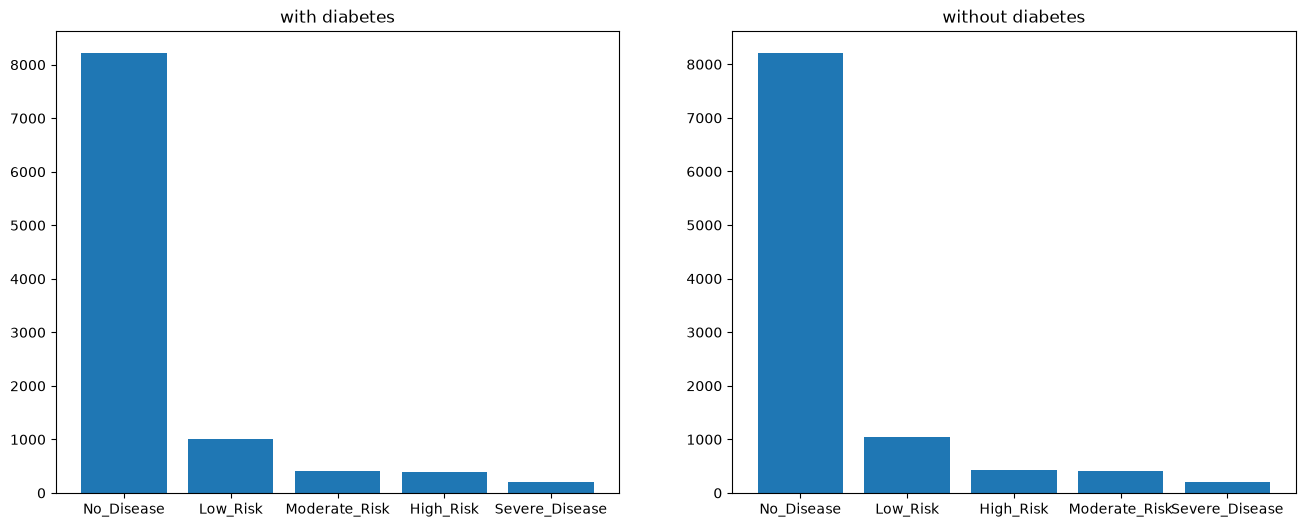

In [11]:
another=df[["Diabetes mellitus (yes/no)","Target"]]
print(another)
temp=df.groupby("Diabetes mellitus (yes/no)")["Target"]
withyes=temp.get_group("yes").value_counts()
withno=temp.get_group("no").value_counts()
fig,axs=plt.subplots(1,2,figsize=(16,6))
axs[0].set_title("with diabetes")
axs[1].set_title("without diabetes")
axs[0].bar(withyes.index,withyes.values)
axs[1].bar(withno.index,withno.values)
plt.show()

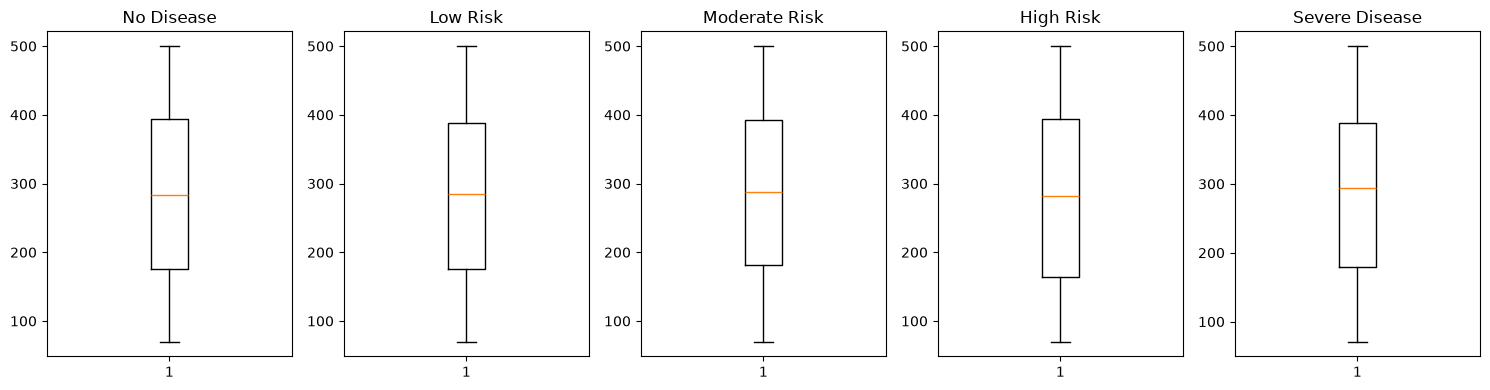

                      mean  median
Target                            
High_Risk       281.270402   282.0
Low_Risk        284.034567   285.5
Moderate_Risk   286.532278   288.0
No_Disease      284.755173   284.0
Severe_Disease  285.529268   294.5


In [15]:
store=df.groupby("Target")['Random blood glucose level (mg/dl)']
a = store.get_group("No_Disease").tolist()
b = store.get_group("Low_Risk").tolist()
c = store.get_group("Moderate_Risk").tolist()
d = store.get_group("High_Risk").tolist()
e = store.get_group("Severe_Disease").tolist()
fig, axes = plt.subplots(1, 5, figsize=(15, 4))
axes[0].set_title("No Disease")
axes[1].set_title("Low Risk")
axes[2].set_title("Moderate Risk")
axes[3].set_title("High Risk")
axes[4].set_title("Severe Disease")
axes[0].boxplot(a)
axes[1].boxplot(b)
axes[2].boxplot(c)
axes[3].boxplot(d)
axes[4].boxplot(e)
plt.tight_layout()
plt.show()
temp=store.agg(["mean","median"])
print(temp)